# Install & Import

In [ ]:
!pip install optuna scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 15.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import optuna

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the Dataset

In [ ]:
import pandas as pd

import os
file_path = "../../Dataset/Pre-Processed Dataset/Before_remove@and#/combined_dataset.csv"
if not os.path.exists(file_path):
    file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

# Contoh: anggap df sudah ada
# df['clean_text'], df['encoded_label']

X = df['clean_text'].astype(str)
y = df['encoded_label']

# ==========================
# Train–Val–Test Split
# ==========================

# Step 1: Test set 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: From remaining 80%, take 12.5% as validation
# 12.5% dari 80% = 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)


# Optuna Objective Function (with TF-IDF + Stratified KFold)

In [ ]:
def objective(trial):

    # Hyperparameters
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
    gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True) if kernel == "rbf" else "scale"

    model = SVC(C=C, kernel=kernel, gamma=gamma, probability=True,
    random_state=42)

    # Stratified K-Fold on TRAIN SET ONLY
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_scores = []

    X_arr = X_train_tfidf
    y_arr = y_train.values

    for train_idx, valid_idx in skf.split(X_arr, y_arr):
        X_tr, X_va = X_arr[train_idx], X_arr[valid_idx]
        y_tr, y_va = y_arr[train_idx], y_arr[valid_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)

        f1_scores.append(f1_score(y_va, preds))

    return np.mean(f1_scores)


# Jalankan Optuna Study (n_trials = 50)

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)     # bisa 50–100 untuk akurasi lebih stabil


[I 2025-11-25 03:27:53,599] A new study created in memory with name: no-name-34f0eb28-e1e1-42fa-95e5-7b2ba6bcd89e
[I 2025-11-25 03:27:58,443] Trial 0 finished with value: 0.0 and parameters: {'C': 0.47352774959483884, 'kernel': 'rbf', 'gamma': 0.053500431234001666}. Best is trial 0 with value: 0.0.
[I 2025-11-25 03:28:02,017] Trial 1 finished with value: 0.0 and parameters: {'C': 0.010583326854438246, 'kernel': 'linear'}. Best is trial 0 with value: 0.0.
[I 2025-11-25 03:28:05,581] Trial 2 finished with value: 0.0 and parameters: {'C': 0.0037099456874820085, 'kernel': 'rbf', 'gamma': 0.00019002548504644883}. Best is trial 0 with value: 0.0.
[I 2025-11-25 03:28:10,038] Trial 3 finished with value: 0.0 and parameters: {'C': 0.644607885183592, 'kernel': 'rbf', 'gamma': 0.0009321937384523859}. Best is trial 0 with value: 0.0.
[I 2025-11-25 03:28:13,993] Trial 4 finished with value: 0.04761172626722221 and parameters: {'C': 0.6656130216001286, 'kernel': 'rbf', 'gamma': 0.06274719269059026}.

# Hyperparameter Terbaik

In [ ]:
print("Best Hyperparameters:", study.best_trial.params)


Best Hyperparameters: {'C': 2.943518545256506, 'kernel': 'rbf', 'gamma': 0.7087455975220841}


# Train Final Model (dengan hyperparameter terbaik)

In [ ]:
best_params = study.best_trial.params

best_C = best_params["C"]
best_kernel = best_params["kernel"]
best_gamma = best_params["gamma"] if best_kernel == "rbf" else "scale"

final_model = SVC(
    C=best_C,
    kernel=best_kernel,
    gamma=best_gamma,
    probability=True,
    random_state=42
)

# Combine Train + Validation
X_final = vectorizer.fit_transform(pd.concat([X_train, X_val]))
y_final = pd.concat([y_train, y_val]).values

final_model.fit(X_final, y_final)


SVC(C=2.943518545256506, gamma=0.7087455975220841, probability=True,
    random_state=42)

# Evaluate on Test Set

Mapping encoded_label -> class name:
0.0 -> Bullying
1.0 -> Non-bullying

Class names (urutan sesuai encoded label):
['Bullying', 'Non-bullying']

 Final Model F1 Score (Test, macro): 0.8785

 Classification Report:

              precision    recall  f1-score   support

    Bullying     0.8538    0.9474    0.8981       228
Non-bullying     0.9255    0.8011    0.8588       186

    accuracy                         0.8816       414
   macro avg     0.8896    0.8742    0.8785       414
weighted avg     0.8860    0.8816    0.8805       414



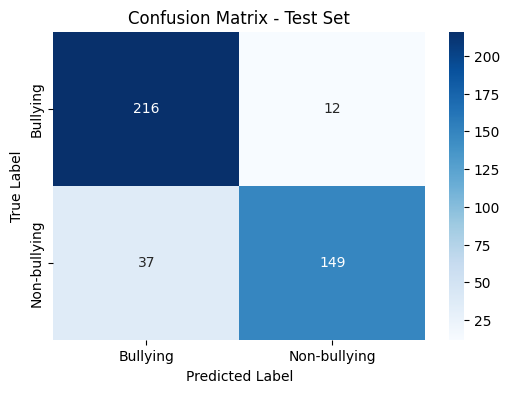

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Prediksi ---
# X_test_tfidf was generated with the vectorizer fitted on X_train only.
# The 'vectorizer' object itself was re-fitted on X_train + X_val in the previous cell.
# We need to transform X_test using the current state of the vectorizer.
y_pred = final_model.predict(vectorizer.transform(X_test))

# --- Mapping label biner ---
label_mapping = {
    0.0: "Bullying",
    1.0: "Non-bullying"
}

# Urutkan sesuai nilai encoded label
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

print("Mapping encoded_label -> class name:")
for k, v in label_mapping.items():
    print(f"{k} -> {v}")

print("\nClass names (urutan sesuai encoded label):")
print(class_names)

# --- Evaluasi ---
f1 = f1_score(y_test, y_pred, average="macro")
print(f"\n Final Model F1 Score (Test, macro): {f1:.4f}")

# Classification Report
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()

# Save Model Configuration Summary :

In [ ]:
import json
from pprint import pprint

# ------------------------------------------------------
# Experiment configuration
# ------------------------------------------------------
experiment_config = {
    "embedding": "tfidf",
    "model": "svm",
    "use_kfold": True,
    "kfold_splits": 5,
    "svm_C": best_params.get("C"),
    "svm_kernel": best_params.get("kernel"),
    "svm_gamma": best_params.get("gamma"),
    "vectorizer_params": {
        "max_features": getattr(vectorizer, "max_features", None),
        "ngram_range": getattr(vectorizer, "ngram_range", None)
    }
}

# ------------------------------------------------------
# Display configuration
# ------------------------------------------------------
print("\nExperiment Configuration:")
pprint(experiment_config)

# JSON-style print
print("\nConfiguration (JSON Format):")
print(json.dumps(experiment_config, indent=4))

# ------------------------------------------------------
# Summary of results
# ------------------------------------------------------
print("\nFinal Evaluation Summary")
print("------------------------")
print(f"Macro F1 Score (Test): {f1:.4f}")
print(f"SVM Kernel: {experiment_config['svm_kernel']}")
print(f"K-Fold CV: {experiment_config['use_kfold']}  |  Splits: {experiment_config['kfold_splits']}")
print()



Experiment Configuration:
{'embedding': 'tfidf',
 'kfold_splits': 5,
 'model': 'svm',
 'svm_C': 2.943518545256506,
 'svm_gamma': 0.7087455975220841,
 'svm_kernel': 'rbf',
 'use_kfold': True,
 'vectorizer_params': {'max_features': None, 'ngram_range': (1, 1)}}

Configuration (JSON Format):
{
    "embedding": "tfidf",
    "model": "svm",
    "use_kfold": true,
    "kfold_splits": 5,
    "svm_C": 2.943518545256506,
    "svm_kernel": "rbf",
    "svm_gamma": 0.7087455975220841,
    "vectorizer_params": {
        "max_features": null,
        "ngram_range": [
            1,
            1
        ]
    }
}

Final Evaluation Summary
------------------------
Macro F1 Score (Test): 0.8785
SVM Kernel: rbf
K-Fold CV: True  |  Splits: 5

